Nom : El jattioui Prenom : Maryame Master : GLCC

--- 1. RÉGRESSION LINÉAIRE SIMPLE ---
Biais (theta0): -195333.33, Coefficient (theta1): 80878.79

--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---
Biais: -159500.00
Coefficients (Expérience, Niveau Étude): [ 133000. -107500.]

--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---
Coefficients (Biais, X, X^2): [ 232166.66666667 -132871.21212121   19431.81818182]



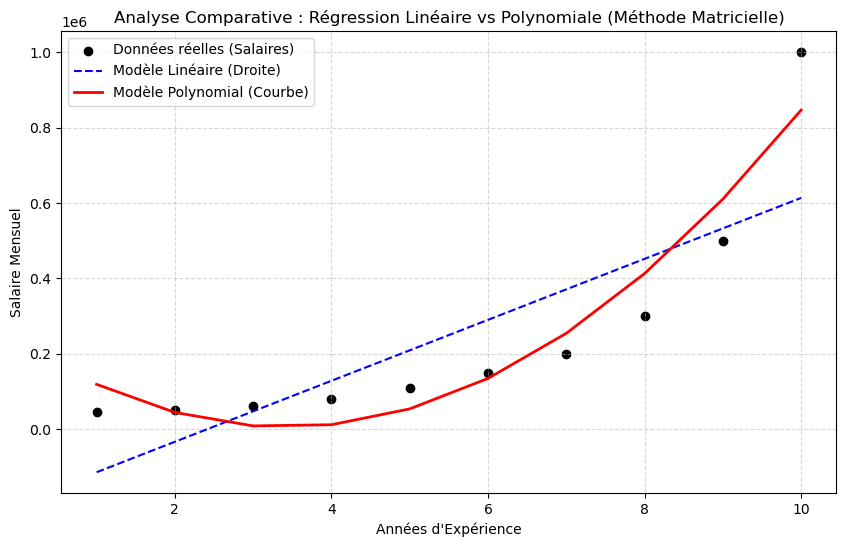

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PRÉPARATION DES DONNÉES
# =================================================================
# X_simple : Variable unique. Représente souvent les années d'expérience.
X_simple = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# X_multiple : Deux variables explicatives. 
# Ici, on étudie l'effet combiné de l'expérience (Col 1) et du niveau d'étude (Col 2).
X_multiple = np.array([
    [1, 1], [2, 1], [3, 2], [4, 2], [5, 3], 
    [6, 3], [7, 4], [8, 4], [9, 5], [10, 5]
])

# y : La variable cible (le salaire). 
# Note : Les valeurs augmentent de façon exponentielle à la fin, ce qui justifie le test polynomial.
y = np.array([45000, 50000, 60000, 80000, 110000, 150000, 200000, 300000, 500000, 1000000])

# =================================================================
# FONCTION CŒUR : L'ÉQUATION NORMALE (Moteur du "From Scratch")
# Cette fonction résout analytiquement le problème de minimisation des moindres carrés.
# Formule mathématique : Theta = (X^T * X)^-1 * X^T * y
# =================================================================
def fit_scratch(X_input, y_target):
    # ÉTAPE A : Ajout du biais (Intercept). 
    # En mathématiques, pour inclure l'ordonnée à l'origine dans le calcul matriciel, 
    # on ajoute une colonne remplie de "1" à notre matrice X.
    X_b = np.c_[np.ones((len(X_input), 1)), X_input]
    
    # ÉTAPE B : Calcul des paramètres optimaux (Theta)
    # .T  : Transposée de la matrice
    # .dot : Produit matriciel
    # np.linalg.inv : Inverse de la matrice
    # Cette ligne unique remplace tout l'entraînement d'un modèle de bibliothèque.
    theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_target)
    
    return theta_best

# =================================================================
# 2. RÉGRESSION LINÉAIRE SIMPLE (Modèle : y = theta0 + theta1*x)
# =================================================================
print("--- 1. RÉGRESSION LINÉAIRE SIMPLE ---")
# On transforme X_simple en matrice colonne (reshape) pour que la fonction puisse le traiter
theta_simple = fit_scratch(X_simple.reshape(-1, 1), y)
print(f"Biais (theta0): {theta_simple[0]:.2f}, Coefficient (theta1): {theta_simple[1]:.2f}\n")

# =================================================================
# 3. RÉGRESSION LINÉAIRE MULTIPLE (Modèle : y = theta0 + theta1*x1 + theta2*x2)
# =================================================================
print("--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---")
# Ici, l'équation normale traite nativement les deux colonnes d'entrée.
theta_mult = fit_scratch(X_multiple, y)
print(f"Biais: {theta_mult[0]:.2f}")
print(f"Coefficients (Expérience, Niveau Étude): {theta_mult[1:]}\n")

# =================================================================
# 4. RÉGRESSION POLYNOMIALE (Modèle : y = theta0 + theta1*x + theta2*x²)
# =================================================================
print("--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---")
# Le secret de la régression polynomiale "from scratch" est de créer soi-même 
# une nouvelle feature : le carré de X. On transforme un problème courbe en problème linéaire.
X_poly_manual = np.c_[X_simple, X_simple**2]
theta_poly = fit_scratch(X_poly_manual, y)
print(f"Coefficients (Biais, X, X^2): {theta_poly}\n")

# =================================================================
# 5. VISUALISATION DES RÉSULTATS
# =================================================================
plt.figure(figsize=(10, 6))
# Affichage des points de données d'origine
plt.scatter(X_simple, y, color='black', label='Données réelles (Salaires)')

# Construction de la prédiction Linéaire : simple multiplication des paramètres trouvés
y_pred_simple = theta_simple[0] + theta_simple[1]*X_simple
plt.plot(X_simple, y_pred_simple, color='blue', linestyle='--', label='Modèle Linéaire (Droite)')

# Construction de la prédiction Polynomiale : inclut le terme au carré (x²)
# On voit ici que la courbe s'adapte beaucoup mieux aux salaires élevés à la fin de carrière.
y_pred_poly = theta_poly[0] + theta_poly[1]*X_simple + theta_poly[2]*(X_simple**2)
plt.plot(X_simple, y_pred_poly, color='red', linewidth=2, label='Modèle Polynomial (Courbe)')

# Mise en forme du graphique pour le rendu académique
plt.title('Analyse Comparative : Régression Linéaire vs Polynomiale (Méthode Matricielle)')
plt.xlabel('Années d\'Expérience')
plt.ylabel('Salaire Mensuel')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()